# Hierarchical Clustering

**Dataset:** Iris (sklearn built-in)  
**Task:** Unsupervised clustering — build a hierarchy of clusters without specifying $K$ in advance

---

## Overview

Unlike K-Means, **hierarchical clustering** builds a **tree of clusters (dendrogram)** rather than a flat partition. You can then cut the dendrogram at any level to obtain any number of clusters.

### Agglomerative Clustering (Bottom-Up)

1. Start with each sample as its own cluster ($n$ clusters)
2. Merge the two **closest** clusters
3. Repeat until all samples are in one cluster

### Linkage Criteria: How to Measure Distance Between Clusters

| Linkage | Distance Between Clusters $A$ and $B$ |
|---------|---------------------------------------|
| **Single** | $\min_{a \in A, b \in B} d(a, b)$ |
| **Complete** | $\max_{a \in A, b \in B} d(a, b)$ |
| **Average** | $\frac{1}{|A||B|} \sum_{a,b} d(a, b)$ |
| **Ward** | Minimize increase in total within-cluster variance |

**Ward linkage** tends to produce the most compact, balanced clusters and is generally the best default.

### Divisive Clustering (Top-Down)

The reverse: start with one cluster and recursively split. Less common in practice.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

np.random.seed(42)
plt.rcParams['font.size'] = 12

## 2. Load and Preprocess Iris

In [2]:
iris = load_iris()
X, y = iris.data, iris.target
target_names = iris.target_names
feature_names = iris.feature_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X.shape}")
print(f"Classes: {target_names}")

Shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


## 3. The Dendrogram

The dendrogram visualizes the merge history. The **height** of each merge indicates the distance between the clusters being merged. A natural number of clusters $K$ corresponds to a horizontal cut where there is a large vertical gap.

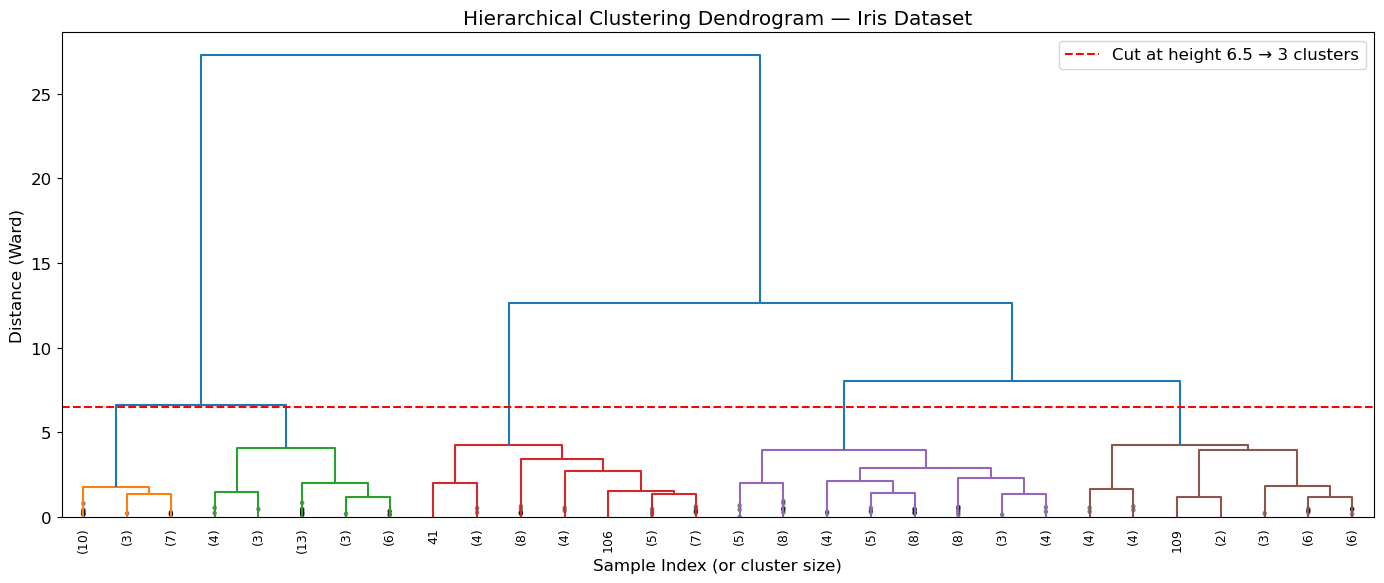

In [3]:
# Compute linkage matrix using Ward's method
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    ax=ax,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=6.5
)
ax.axhline(y=6.5, color='red', linestyle='--', label='Cut at height 6.5 → 3 clusters')
ax.set_xlabel('Sample Index (or cluster size)')
ax.set_ylabel('Distance (Ward)')
ax.set_title('Hierarchical Clustering Dendrogram — Iris Dataset')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Cut the Dendrogram and Evaluate

In [4]:
cluster_labels = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X_scaled)

ari = adjusted_rand_score(y, cluster_labels)
sil = silhouette_score(X_scaled, cluster_labels)

print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score:    {sil:.4f}")

# Cluster vs. true species
df = pd.DataFrame({'True Species': [target_names[i] for i in y], 'Cluster': cluster_labels})
print("\nCluster composition:")
print(pd.crosstab(df['True Species'], df['Cluster']))

Adjusted Rand Index: 0.6153
Silhouette Score:    0.4467

Cluster composition:
Cluster        0   1   2
True Species            
setosa         0  49   1
versicolor    23   0  27
virginica     48   0   2


## 5. Visualize Clusters

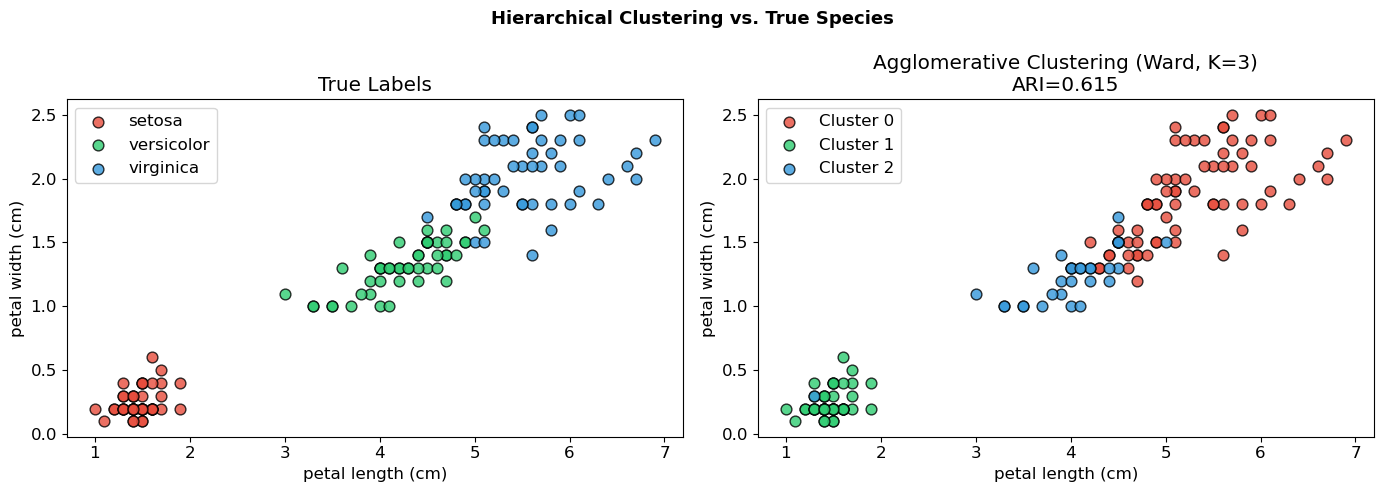

In [5]:
colors = ['#e74c3c', '#2ecc71', '#3498db']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True labels
for cls, color, name in zip([0,1,2], colors, target_names):
    mask = y == cls
    axes[0].scatter(X[mask, 2], X[mask, 3], c=color, label=name,
                    edgecolors='k', s=60, alpha=0.8)
axes[0].set_xlabel(feature_names[2]); axes[0].set_ylabel(feature_names[3])
axes[0].set_title('True Labels'); axes[0].legend()

# Hierarchical cluster labels
for cls, color in zip([0,1,2], colors):
    mask = cluster_labels == cls
    axes[1].scatter(X[mask, 2], X[mask, 3], c=color,
                    edgecolors='k', s=60, alpha=0.8, label=f'Cluster {cls}')
axes[1].set_xlabel(feature_names[2]); axes[1].set_ylabel(feature_names[3])
axes[1].set_title(f'Agglomerative Clustering (Ward, K=3)\nARI={ari:.3f}'); axes[1].legend()

plt.suptitle('Hierarchical Clustering vs. True Species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Compare Linkage Methods

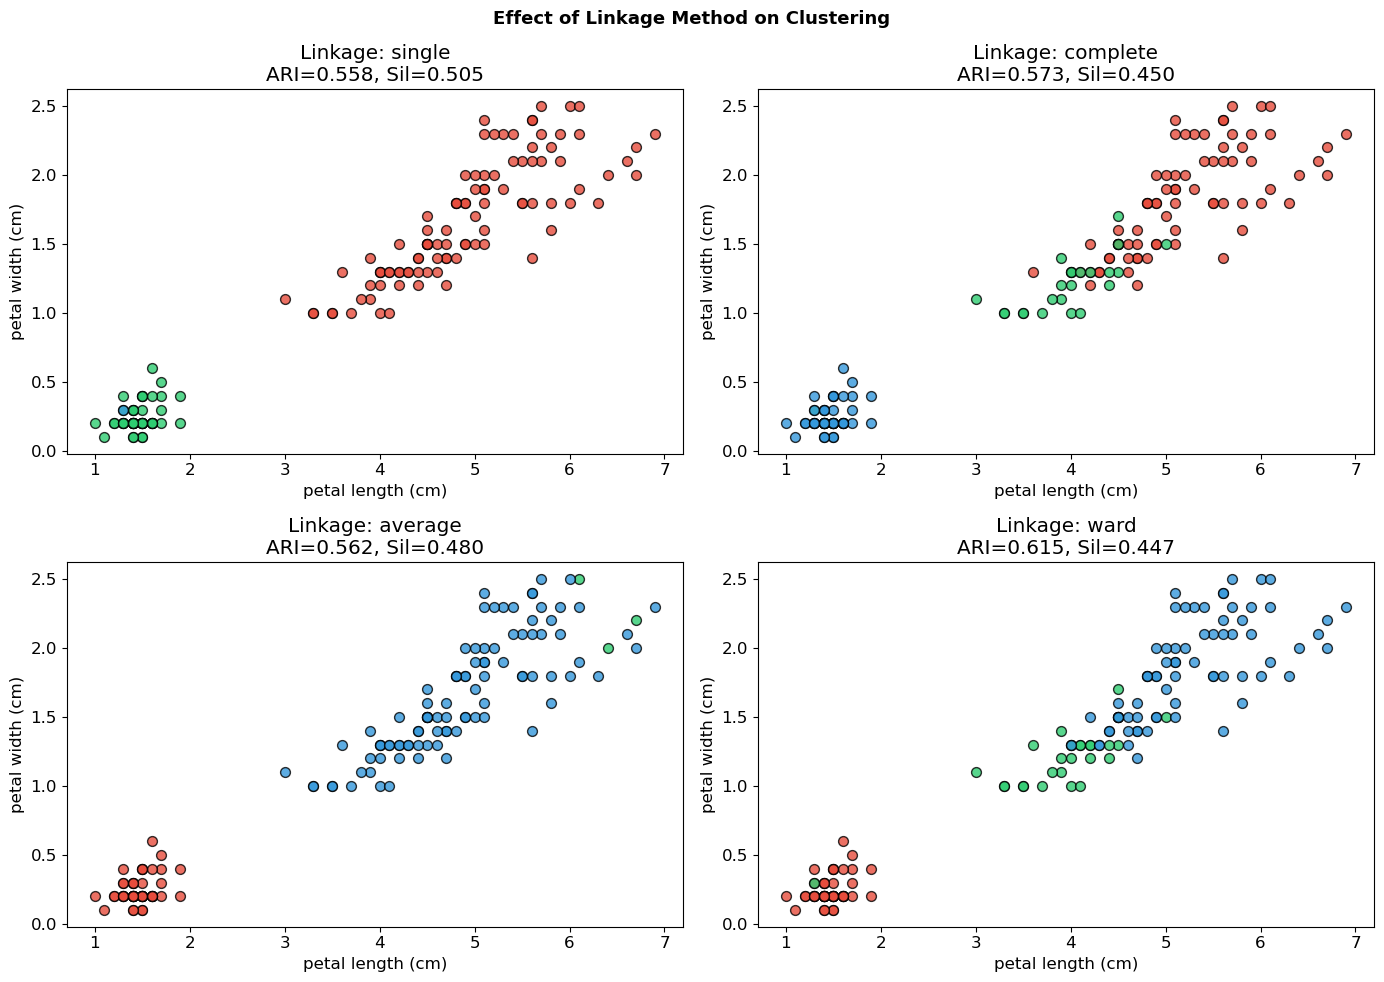

In [6]:
linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, method in zip(axes, linkage_methods):
    Z_m = linkage(X_scaled, method=method)
    labels = fcluster(Z_m, 3, criterion='maxclust') - 1  # 0-indexed
    ari_m  = adjusted_rand_score(y, labels)
    sil_m  = silhouette_score(X_scaled, labels)

    for cls, color in zip([0,1,2], colors):
        mask = labels == cls
        ax.scatter(X[mask, 2], X[mask, 3], c=color,
                   edgecolors='k', s=50, alpha=0.8, label=f'Cluster {cls}')
    ax.set_title(f'Linkage: {method}\nARI={ari_m:.3f}, Sil={sil_m:.3f}')
    ax.set_xlabel(feature_names[2]); ax.set_ylabel(feature_names[3])

plt.suptitle('Effect of Linkage Method on Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Choosing K: Merge Distance Plot

Plot the merge distances in descending order. A large jump suggests the next merge is combining very different clusters — indicating the right $K$.

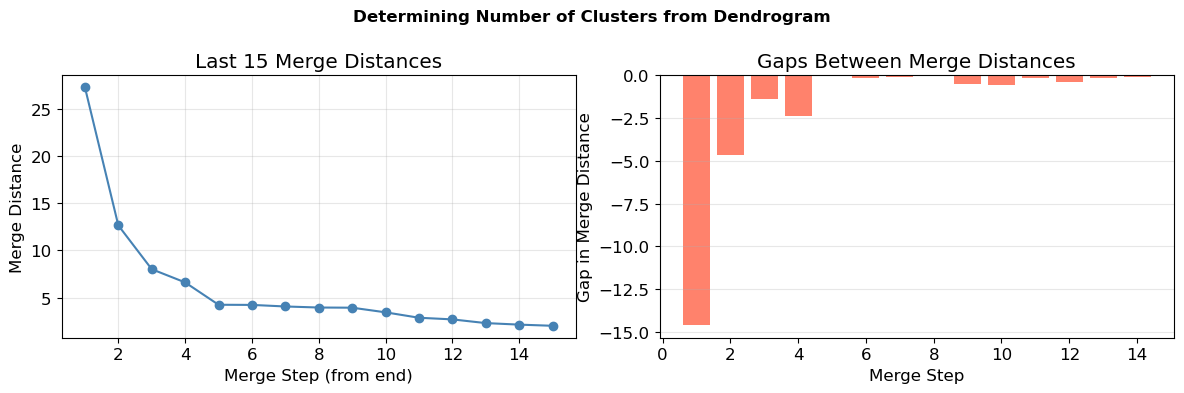

In [7]:
last_merges = Z[-15:, 2][::-1]  # last 15 merge distances, reversed
gaps = np.diff(last_merges)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(last_merges)+1), last_merges, 'o-', color='steelblue')
axes[0].set_xlabel('Merge Step (from end)'); axes[0].set_ylabel('Merge Distance')
axes[0].set_title('Last 15 Merge Distances')
axes[0].grid(alpha=0.3)

axes[1].bar(range(1, len(gaps)+1), gaps, color='tomato', alpha=0.8)
axes[1].set_xlabel('Merge Step'); axes[1].set_ylabel('Gap in Merge Distance')
axes[1].set_title('Gaps Between Merge Distances')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Determining Number of Clusters from Dendrogram', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Summary

### Key Takeaways

- Hierarchical clustering produces a full **dendrogram** — no need to choose $K$ upfront; cut at any level.
- **Ward linkage** minimizes within-cluster variance and generally gives the most compact clusters.
- **Single linkage** is susceptible to chaining (elongated clusters); **complete/average** are more robust.
- The dendrogram reveals **natural structure** in data that flat clustering methods might miss.
- Hierarchical clustering scales as $O(n^2 \log n)$ — it's slower than K-Means for large datasets.
- The **merge distance plot** and large gaps in the dendrogram can guide selection of $K$.